In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Load CSV
df = pd.read_csv("merged_file.csv")

/var/folders/1f/krwy3h6948n5qhc5csbfcdph0000gp/T/ipykernel_84772/3435920307.py:2: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_file.csv")


Filter the dataset to include only:

* Residential properties

* Single-family homes

* Located in California

In [3]:
# Filter for usable rows
df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence') &
    (df['StateOrProvince'] == 'CA')
]

Define which columns (features) will be used as input (X) for the model and which one is the target (y) that the model will predict. These selected features include numeric attributes (e.g., LivingArea, GarageSpaces), boolean flags (e.g., PoolPrivateYN), and categorical features (e.g., CountyOrParish, City).

In [4]:
# Select features
features = [
    "LivingArea", "LotSizeArea", "GarageSpaces", "BathroomsTotalInteger",
    "BedroomsTotal", "Stories", "YearBuilt", "Latitude", "Longitude",
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "ParkingTotal",
    "FireplaceYN", "CountyOrParish", "City"
]
target = "ClosePrice"


Create a new DataFrame called df_model by extracting only the selected feature columns and the target (ClosePrice) from the original dataset df. The .copy() ensures the new DataFrame is independent of the original, preventing unintended side effects during processing.

In [5]:
df_model = df[features + [target]].copy()

Display the first few rows of the newly created df_model DataFrame to verify that the feature selection and subsetting were done correctly. This step helps visually confirm the structure and contents of the data before proceeding with preprocessing or modeling.

In [6]:
df_model.head()

,LivingArea,LotSizeArea,GarageSpaces,BathroomsTotalInteger,BedroomsTotal,Stories,YearBuilt,Latitude,Longitude,ViewYN,PoolPrivateYN,AttachedGarageYN,ParkingTotal,FireplaceYN,CountyOrParish,City,ClosePrice
11,1656.0,13800.0,0.0,2.0,4.0,1.0,1960.0,32.821023,-116.941739,False,False,NaN,4.0,False,San Diego,El Cajon,530000.0
12,1558.0,3000.0,0.0,2.0,4.0,1.0,1972.0,32.826301,-117.103107,False,False,NaN,0.0,False,San Diego,San Diego,700000.0
13,2286.0,NaN,2.0,3.0,4.0,2.0,1999.0,32.921240,-117.224366,False,False,True,4.0,True,San Diego,San Diego,1680000.0
14,2695.0,11761.0,3.0,3.0,3.0,1.0,1990.0,33.691553,-116.306923,True,True,True,3.0,True,Riverside,La Quinta,1195000.0
16,NaN,15365.0,NaN,5.0,4.0,1.0,1955.0,34.136178,-118.432085,True,NaN,NaN,0.0,True,Los Angeles,Sherman Oaks,3800000.0


Drop rows that have null values for the target variable (ClosePrice)

In [7]:
df_model.dropna(subset=[target], inplace=True)

Round coordinates to 2 decimal places to reduce noise and help with grouping properties into approximate regions.

In [8]:
df_model["Latitude"] = df_model["Latitude"].round(2)
df_model["Longitude"] = df_model["Longitude"].round(2)

Check column data types to inform preprocessing strategies

In [9]:
df_model.dtypes

LivingArea               float64
LotSizeArea              float64
GarageSpaces             float64
BathroomsTotalInteger    float64
BedroomsTotal            float64
Stories                  float64
YearBuilt                float64
Latitude                 float64
Longitude                float64
ViewYN                    object
PoolPrivateYN             object
AttachedGarageYN          object
ParkingTotal             float64
FireplaceYN               object
CountyOrParish            object
City                      object
ClosePrice               float64
dtype: object

Split the feature set into numerical and categorical columns.

* Needed for building preprocessing pipelines (e.g., scaling numerical features, encoding categorical ones).

In [10]:
# Separate numerical and categorical features
numerical_features = df_model[features].select_dtypes(include=['int64','float64']).columns.tolist()

categorical_features = df_model[features].select_dtypes(include='object').columns.tolist()

In [11]:
numerical_features

['LivingArea',
 'LotSizeArea',
 'GarageSpaces',
 'BathroomsTotalInteger',
 'BedroomsTotal',
 'Stories',
 'YearBuilt',
 'Latitude',
 'Longitude',
 'ParkingTotal']

In [12]:
categorical_features

['ViewYN',
 'PoolPrivateYN',
 'AttachedGarageYN',
 'FireplaceYN',
 'CountyOrParish',
 'City']

Display the number of unique values in two high-cardinality categorical variables to assess the potential dimensionality explosion due to one-hot encoding

In [13]:
print("Unique Cities:", df_model["City"].nunique())
print("Unique Counties:", df_model["CountyOrParish"].nunique())

Unique Cities: 864
Unique Counties: 56


Define a utility function to reduce cardinality. It retains only the top N frequent categories in a column, replacing all others with "Other". This is crucial for efficient modeling and prevents one-hot encoding from creating too many sparse features.

In [14]:
def group_top_n_categories(df, column, top_n=10):
    top_categories = df[column].value_counts().nlargest(top_n).index
    return df[column].apply(lambda x: x if x in top_categories else "Other")

Apply the above function to the "City" and "CountyOrParish" columns to cap their cardinality at 10 to mitigate model overfitting and improve 
computational efficiency.

In [15]:
df_model["City"] = group_top_n_categories(df_model, "City", top_n=10)
df_model["CountyOrParish"] = group_top_n_categories(df_model, "CountyOrParish", top_n=10)

Verify that the grouping worked as expected by printing the number of unique categories remaining after transformation (should be 11 including "Other")

In [16]:
print("Unique Cities:", df_model["City"].nunique())
print("Unique Counties:", df_model["CountyOrParish"].nunique())

Unique Cities: 11
Unique Counties: 11


Define preprocessing steps for both numerical and categorical features:

* Numerical pipeline: handles missing values and scaling.

* Categorical pipeline: imputes missing values and performs one-hot encoding.

* Combines both using ColumnTransformer so that the full preprocessing can be applied in one step.

In [17]:
# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

Separate features (X) from the target (y = ClosePrice) and apply the preprocessing steps defined above. This prepares the data for model training.

In [67]:
# Preprocess data
X = df_model.drop(columns=[target])
y = df_model[target]
X_processed = preprocessor.fit_transform(X)

Train-test split

In [68]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

* Train a Ridge regression model.

* Extract the model’s coefficients and match them to their respective feature names from the preprocessor.

* Create a DataFrame of feature importances (coefficients) and display the top 10 most impactful features.

In [69]:
# 5. Train Ridge Regression on preprocessed features
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# 6. Get feature names from fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# 7. Now match shapes and create coefficient DataFrame
print(f"Feature names: {len(feature_names)}, Coefficients: {len(ridge_model.coef_)}")

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_model.coef_
})

# Sort by absolute value
top_coef = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)

# Show top 10
print(top_coef.head(10))

Feature names: 40, Coefficients: 40
                               Feature   Coefficient
27     cat__CountyOrParish_Santa Clara  1.382893e+06
0                      num__LivingArea  8.276618e+05
23       cat__CountyOrParish_Riverside -7.500397e+05
24  cat__CountyOrParish_San Bernardino -6.050247e+05
32               cat__City_Los Angeles  5.113382e+05
38                  cat__City_San Jose -5.059455e+05
18         cat__CountyOrParish_Alameda  4.545335e+05
30                 cat__City_Lancaster -4.166313e+05
34                   cat__City_Oakland -3.666283e+05
28         cat__CountyOrParish_Ventura -3.605882e+05


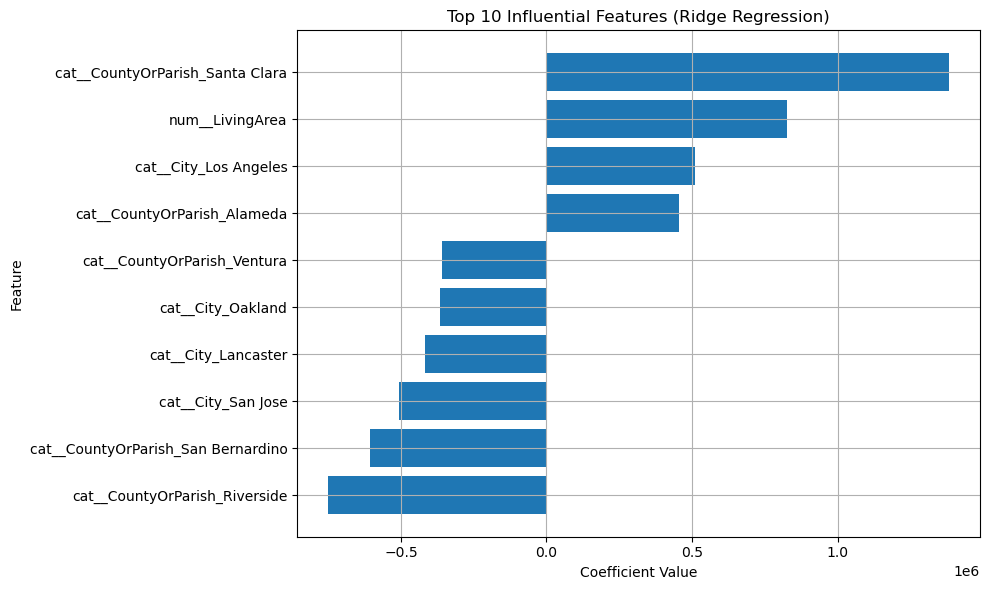

In [75]:
import matplotlib.pyplot as plt

# Plot top 10 features
top_10 = top_coef.head(10).sort_values("Coefficient")
plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Coefficient"])
plt.title("Top 10 Influential Features (Ridge Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()


Use RidgeCV and LassoCV to perform cross-validation over specified alpha values and determine the best regularization strength for Ridge and Lasso Regression. This helps optimize the model’s bias-variance tradeoff and potentially improves performance.

In [70]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_cv.alpha_)

lasso_cv = LassoCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_cv.alpha_)

Best Ridge alpha: 100.0
Best Lasso alpha: 10.0


Define preprocessing pipelines

In [71]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=ridge_cv.alpha_),
    "Lasso Regression": Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

In [72]:
from math import sqrt

Fit each model on the processed training data and evaluates them using R² and RMSE on the test data. The results are saved to a DataFrame and printed in descending order of R² to identify the best-performing linear model.

In [73]:
# Evaluation
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = sqrt(mean_squared_error(y_test, preds))
    results.append((name, r2, rmse))

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
print(results_df.sort_values(by="R2 Score", ascending=False))

                   Model  R2 Score           RMSE
1       Ridge Regression  0.522684  973677.830709
2       Lasso Regression  0.521852  974526.442602
0      Linear Regression  0.521297  975091.769610
3  ElasticNet Regression  0.506748  989798.414484


In [74]:
#!pip install xgboost

In [25]:
# Use only imputation + encoding (no scaling) for tree models
tree_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
tree_cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
tree_preprocessor = ColumnTransformer([
    ("num", tree_num_pipeline, numerical_features),
    ("cat", tree_cat_pipeline, categorical_features)
])

In [26]:
X_tree_processsed = tree_preprocessor.fit_transform(X)

In [27]:
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(X_tree_processsed, y, test_size=0.2, random_state=34)

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

Perform a grid search over n_estimators and max_depth for the Random Forest to identify the best combination of hyperparameters. Improves model generalization by preventing overfitting or underfitting.

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_tree_train, y_tree_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 5, 'n_estimators': 150}


In [30]:
best_rf = grid_search.best_estimator_
preds = best_rf.predict(X_tree_test)

print("R2 Score:", r2_score(y_tree_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_tree_test, preds)))

R2 Score: -0.12239854923472548
RMSE: 1929925.6876965098


Prepare tree-based models

In [31]:
# Dictionary of additional models
tree_models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=grid_search.best_params_['n_estimators'], max_depth=grid_search.best_params_['max_depth'], random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
}

Evaluate tree-based models

In [32]:
# Evaluate and compare
tree_results = []
for name, model in tree_models.items():
    model.fit(X_tree_train, y_tree_train)
    preds = model.predict(X_tree_test)
    r2 = r2_score(y_tree_test, preds)
    rmse = sqrt(mean_squared_error(y_tree_test, preds))
    tree_results.append((name, r2, rmse))

In [33]:
# Display results
tree_results_df = pd.DataFrame(tree_results, columns=["Model", "R2 Score", "RMSE"])
print(tree_results_df.sort_values(by="R2 Score", ascending=False))

               Model  R2 Score          RMSE
0      Decision Tree  0.394451  1.417560e+06
3            XGBoost  0.127786  1.701291e+06
1      Random Forest -0.122399  1.929926e+06
2  Gradient Boosting -0.378720  2.138972e+06


In [34]:
all_results_df = pd.concat([results_df, tree_results_df], ignore_index=True)
print(all_results_df.sort_values(by="R2 Score", ascending=False))

                   Model  R2 Score          RMSE
1       Ridge Regression  0.522684  9.736778e+05
2       Lasso Regression  0.521852  9.745264e+05
0      Linear Regression  0.521297  9.750918e+05
3  ElasticNet Regression  0.506748  9.897984e+05
4          Decision Tree  0.394451  1.417560e+06
7                XGBoost  0.127786  1.701291e+06
5          Random Forest -0.122399  1.929926e+06
6      Gradient Boosting -0.378720  2.138972e+06


In [35]:
print("X _train shape:", X_train.shape)

X _train shape: (49504, 40)


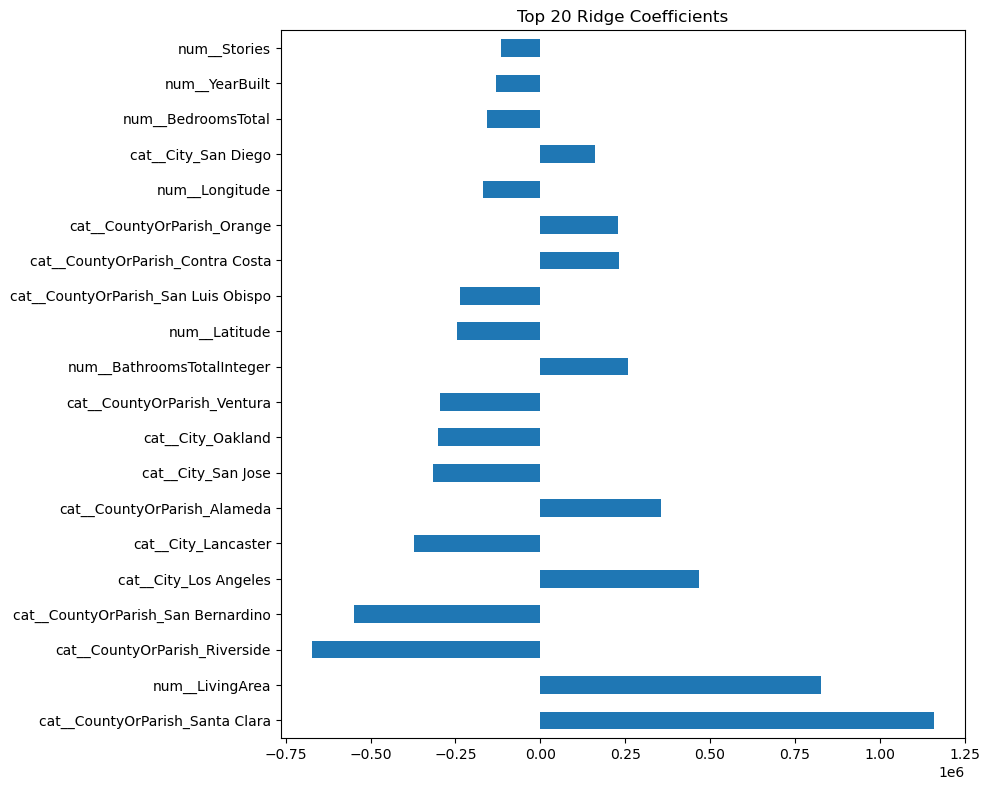

In [36]:
ridge_coeffs = pd.Series(ridge_cv.coef_, index=preprocessor.get_feature_names_out())
ridge_coeffs = ridge_coeffs.sort_values(key=abs, ascending=False)

ridge_coeffs.head(20).plot(kind="barh", figsize=(10, 8), title="Top 20 Ridge Coefficients")
plt.tight_layout()
plt.show()

Log-transform target variable for Ridge regression

In [37]:
y_log = np.log1p(y)
y_train_log, y_test_log = np.log1p(y_train), np.log1p(y_test)

# Train Ridge on log-transformed target
ridge_cv_log = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
ridge_cv_log.fit(X_train, y_train_log)

# Evaluate
preds_log = np.expm1(ridge_cv_log.predict(X_test))
r2 = r2_score(y_test, preds_log)
#rmse = mean_squared_error(y_test, preds_log, squared=False)
rmse = sqrt(mean_squared_error(y_test, preds_log))
print("Log-Ridge R2:", r2)
print("Log-Ridge RMSE:", rmse)

Log-Ridge R2: -24908.014032621402
Log-Ridge RMSE: 222428625.16380766


That's a very poor result — and unusually worse than any of the previous models — which strongly suggests that log-transforming the target variable (ClosePrice) is not helping here.

In [38]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=20)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

ridge_sel = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
ridge_sel.fit(X_train_selected, y_train)
preds = ridge_sel.predict(X_test_selected)
print("Selected Ridge R2:", r2_score(y_test, preds))

Selected Ridge R2: 0.5145269620621014


While feature selection simplified the model and may help with interpretability, it slightly reduced performance. It likely means:

* The original preprocessing already removed most irrelevant/noisy features.

* Ridge (with regularization) was already doing implicit feature selection.

* The selected k features omitted some weakly predictive but complementary variables.

In [39]:
import joblib

joblib.dump(ridge_cv, "ridge_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [40]:
from sklearn.cluster import KMeans
from math import radians, sin, cos, sqrt, atan2

In [41]:
# Step 1: KMeans clustering on Lat/Lon
df_model["Latitude_r"] = df_model["Latitude"].round(2)
df_model["Longitude_r"] = df_model["Longitude"].round(2)

In [42]:
coords = df_model[["Latitude_r", "Longitude_r"]].dropna()
kmeans = KMeans(n_clusters=5, random_state=42)
region_labels = kmeans.fit_predict(coords)

Create a RegionCluster variable by rounding latitude and longitude into coarse buckets, representing neighborhood-like areas. Also calculate DistanceToLA, which measures the Euclidean distance to downtown Los Angeles using approximate latitude/longitude coordinates. These features aim to capture spatial patterns affecting property prices.

In [43]:
# Assign cluster labels back
df_model.loc[coords.index, "RegionCluster"] = region_labels.astype(int)

In [44]:
# Step 2: Distance to Los Angeles City Center (34.0522, -118.2437)
def haversine(lat1, lon1, lat2=34.0522, lon2=-118.2437):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [45]:
df_model["DistanceToLA"] = df_model.apply(
    lambda row: haversine(row["Latitude"], row["Longitude"]) if pd.notnull(row["Latitude"]) else np.nan,
    axis=1
)

Add two new features, LogLivingArea and LogLotSize, to the dataset by applying the natural logarithm transformation. This helps to reduce skewness in the distribution of these variables and can improve model performance and stability.

In [46]:
# Step 3: Log-transformed features
df_model["LogLivingArea"] = np.log1p(df_model["LivingArea"])
df_model["LogLotSize"] = np.log1p(df_model["LotSizeArea"])

Define final feature list for modeling


In [47]:
feature_cols = [
    "BedroomsTotal", "BathroomsTotalInteger", "GarageSpaces", "ParkingTotal", "YearBuilt",
    "Stories", "LivingArea", "LotSizeArea", "City", "CountyOrParish", "FireplaceYN",
    "PoolPrivateYN", "ViewYN", "AttachedGarageYN",
    "RegionCluster", "DistanceToLA", "LogLivingArea", "LogLotSize"
]

In [48]:
# --- Step 2: Filter data ---
df_model_final = df_model[feature_cols + [target]].copy()

In [49]:
# Drop rows with missing target
df_model_final = df_model_final[df_model_final[target].notnull()]

In [50]:
# --- Step 3: Train/test split ---
X_fin = df_model_final.drop(columns=[target])
y_fin = df_model_final[target]

In [51]:
X_fin_train, X_fin_test, y_fin_train, y_fin_test = train_test_split(X_fin, y_fin, test_size=0.2, random_state=42)

In [52]:
# --- Step 4: Update preprocessing pipelines ---
numerical_features_fin = X_fin.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_fin = X_fin.select_dtypes(include='object').columns.tolist()

In [53]:
num_pipeline_fin = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline_fin = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_fin = ColumnTransformer([
    ("num", num_pipeline_fin, numerical_features_fin),
    ("cat", cat_pipeline_fin, categorical_features_fin)
])

In [54]:
# --- Step 5: Fit and transform ---
X_train_processed = preprocessor_fin.fit_transform(X_fin_train)
X_test_processed = preprocessor_fin.transform(X_fin_test)

Define linear models for evalution

In [55]:
# --- Step 6: Retrain models ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=lasso_cv.alpha_),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [56]:
results = []
for name, model in models.items():
    model.fit(X_train_processed, y_fin_train)
    preds = model.predict(X_test_processed)
    r2 = r2_score(y_fin_test, preds)
    rmse = sqrt(mean_squared_error(y_fin_test, preds))
    results.append((name, r2, rmse))

# --- Step 7: Show updated results ---
results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
print(results_df.sort_values(by="R2 Score", ascending=False))

                   Model  R2 Score           RMSE
0      Linear Regression  0.559964  934881.255247
2       Lasso Regression  0.559894  934955.238054
1       Ridge Regression  0.559891  934958.993764
3  ElasticNet Regression  0.540526  955306.617720


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.207e+16, tolerance: 1.432e+14
  model = cd_fast.enet_coordinate_descent(


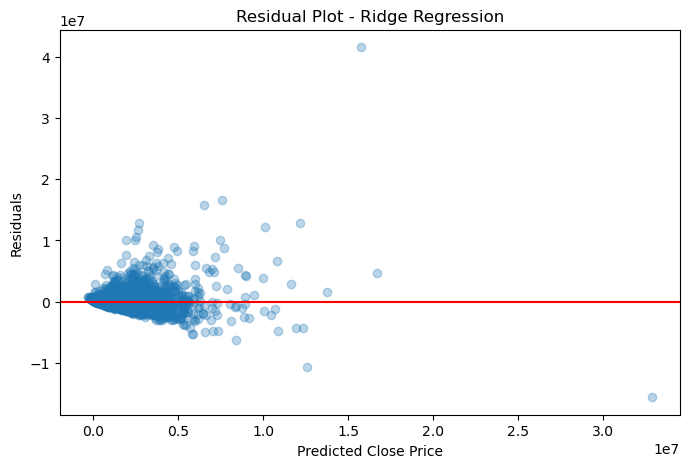

In [57]:
import matplotlib.pyplot as plt

ridge_preds = models["Ridge Regression"].predict(X_test_processed)
residuals = y_test - ridge_preds

plt.figure(figsize=(8, 5))
plt.scatter(ridge_preds, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted Close Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Ridge Regression")
plt.show()
